# 04 · 进阶:权力算子(9 个动词 × 4 种权力)
主册「只调高度」只放开一个自由度。但真实的权力改的是**形态语法**:开发商把板楼拆成细针塔、
居民把大院细分成自建小屋、政府把高度向权力重心收拢。这本把这些「动词」教给你。

> 数据、角色、读法都和主册一样;变的是——**权力现在可以改几何,不只是高度**。

## 怎么执行
- 点一格,按 **Shift+Enter** 执行;或选单 Run → Run All Cells 从头跑。
- 结果与图会显示在该格下面。代码都在 `engine/` 文件夹,平时不用打开。

In [1]:
# 让 notebook 找到 engine 里的代码(这格不用改,直接执行)
import sys, os
sys.path.insert(0, os.path.abspath("engine"))
# 清掉旧的引擎模块缓存:改了 config/engine 后,重跑本格即刻生效(免重启内核)
for _m in [k for k in list(sys.modules) if k in ("config", "common", "operators", "measure")
           or k == "plots" or k.startswith("plots.") or k == "prints" or k.startswith("prints.")]:
    del sys.modules[_m]
import config, common as C, plots, prints
prints.ready()
plots.capture("04")   # 开启自动存图:本册每张图都会存到 out/<slug>/Step_04/<时间戳>/

就绪 ·  当前站点 SLUG = lujiazui ( 陆家嘴街道 )


'20260701_034730'

In [2]:
import operators as ops, measure as M
df = C.assign_all(C.current_buildings(config.SLUG))
recs = C.to_recs(df)            # 算子的工作单位:[{geom, h, sh, frozen}]
prints.vocab(recs)

陆家嘴街道 · 3263 栋。算子词汇:
   ['freeze', 'weight_height', 'concentrate', 'split_to_towers', 'slim', 'densify', 'infill', 'level', 'open_ground']


## 一、9 个原子算子 = power 对 form 的"动词"
| 算子 | 做什么 | 谁常用 |
|---|---|---|
| `freeze` | 锁定不动 | state / 遗产 |
| `weight_height` | 按权重重分配高度 | 政府集权 |
| `concentrate` | 高度向权力重心收拢 | 政府集权(单峰) |
| `split_to_towers` | 大板楼拆成 k 座塔 | 开发商 |
| `slim` | footprint 缩、高度补偿(塔化) | 开发商 |
| `densify` | 抬高度 = 加 GFA | 开发商 |
| `infill` | 大体量细分成自建小单元 | 居民自建 |
| `level` | 高度趋同 | 居民 / 共享 |
| `open_ground` | 缩私有 footprint 释放共享地面 | 共享平权 |

每个都是纯函数 `recs -> recs`,参数可改、可单独演示。下面看两个。

## 二、算子图谱:单个动词的 before / after
**拆板成塔** `split_to_towers`:把大 footprint 沿长轴拆成 3 块(高度不变 → GFA 守恒)。

  -> saved out\lujiazui\Step_04\20260701_034730\01_operator_demo.png


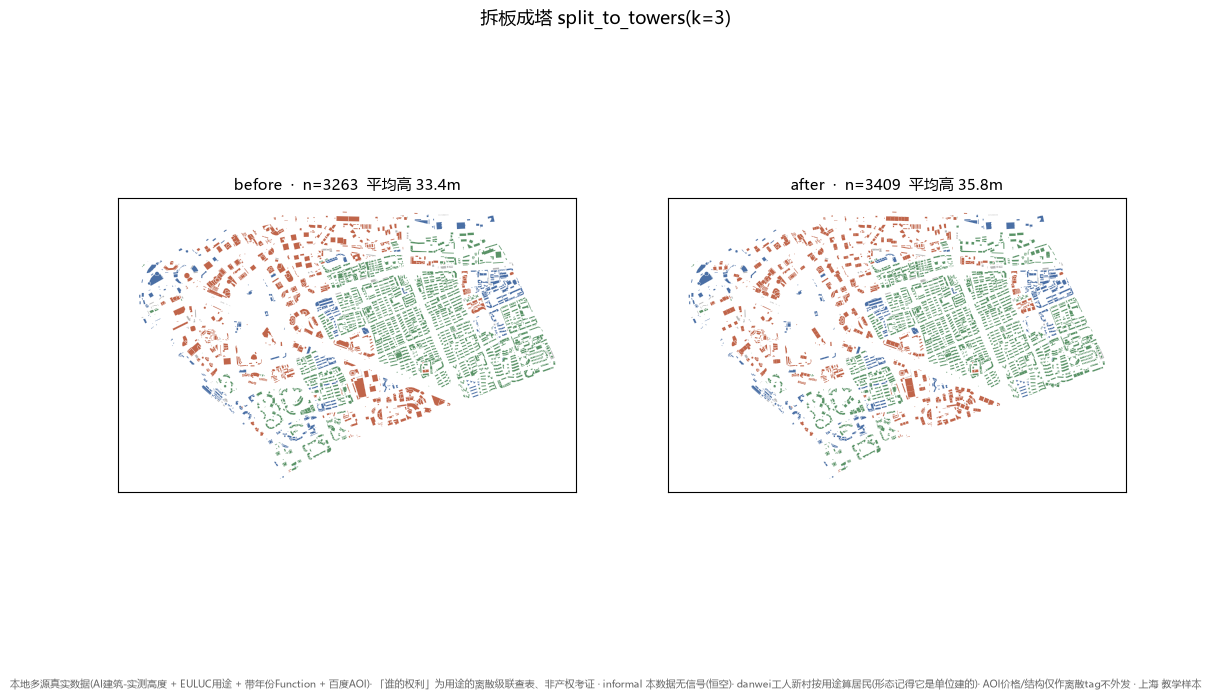

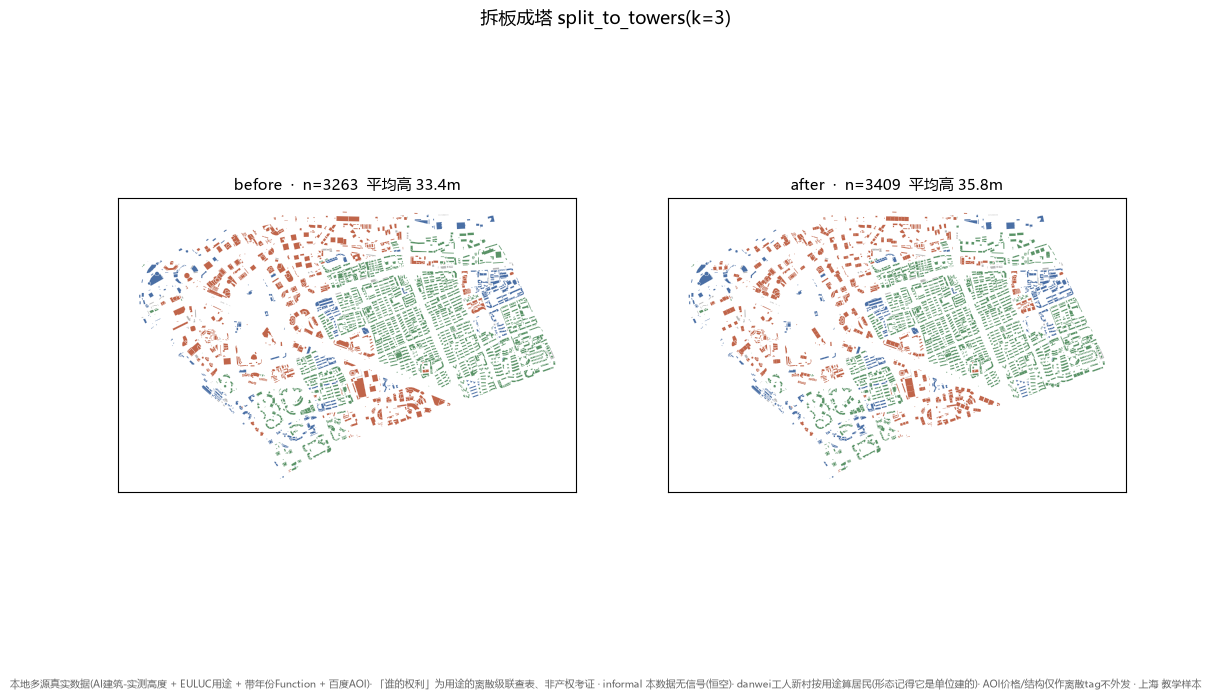

In [3]:
b = ops.freeze(recs, who=["state"])                                   # 先锁定政府公共
a = ops.split_to_towers(b, target=["resident", "developer"], above_m2=1500, k=3)
plots.operator_demo(b, a, "拆板成塔 split_to_towers(k=3)")

**居民自建** `infill`:把大体量细分成自建小单元(细粒、低层、有机)。看栋数怎么暴涨。

  -> saved out\lujiazui\Step_04\20260701_034730\02_operator_demo.png


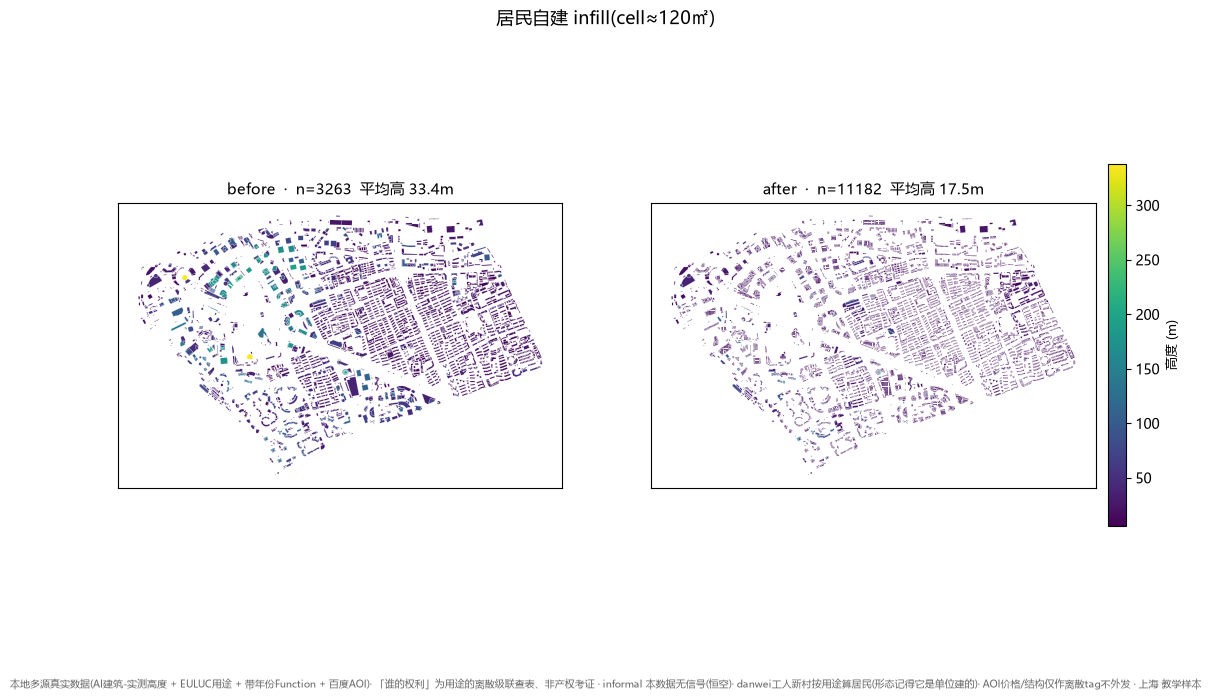

  -> saved out\lujiazui\Step_04\20260701_034730\03_operator_demo.png


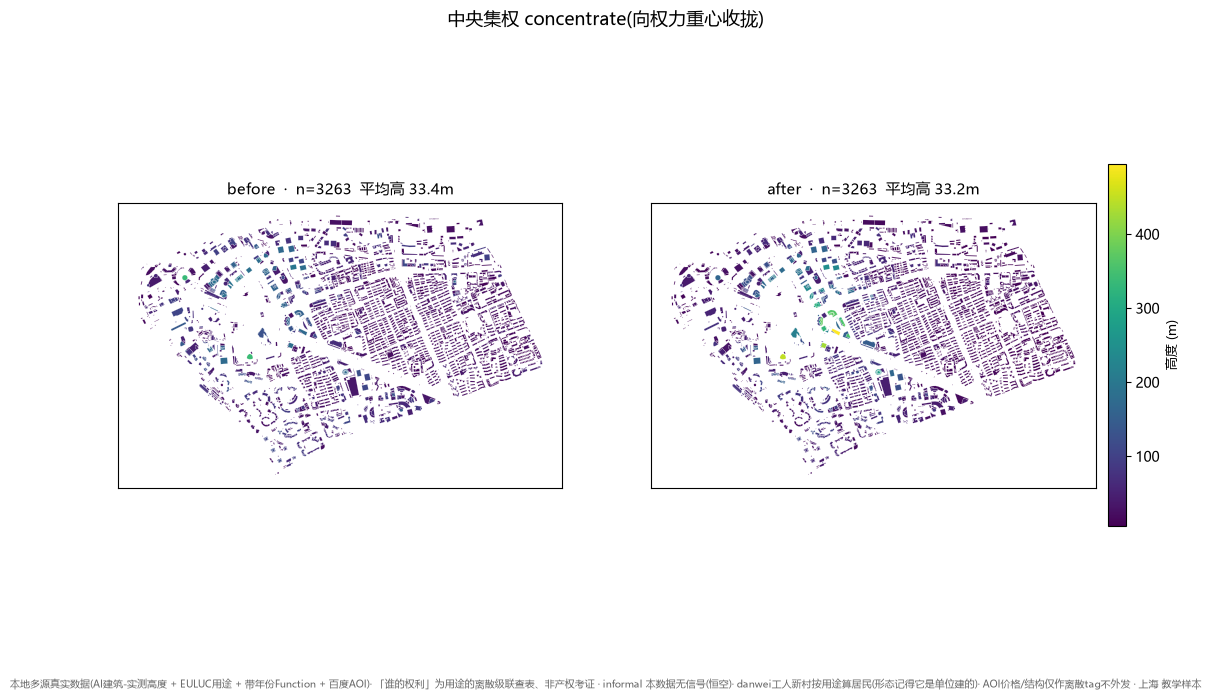

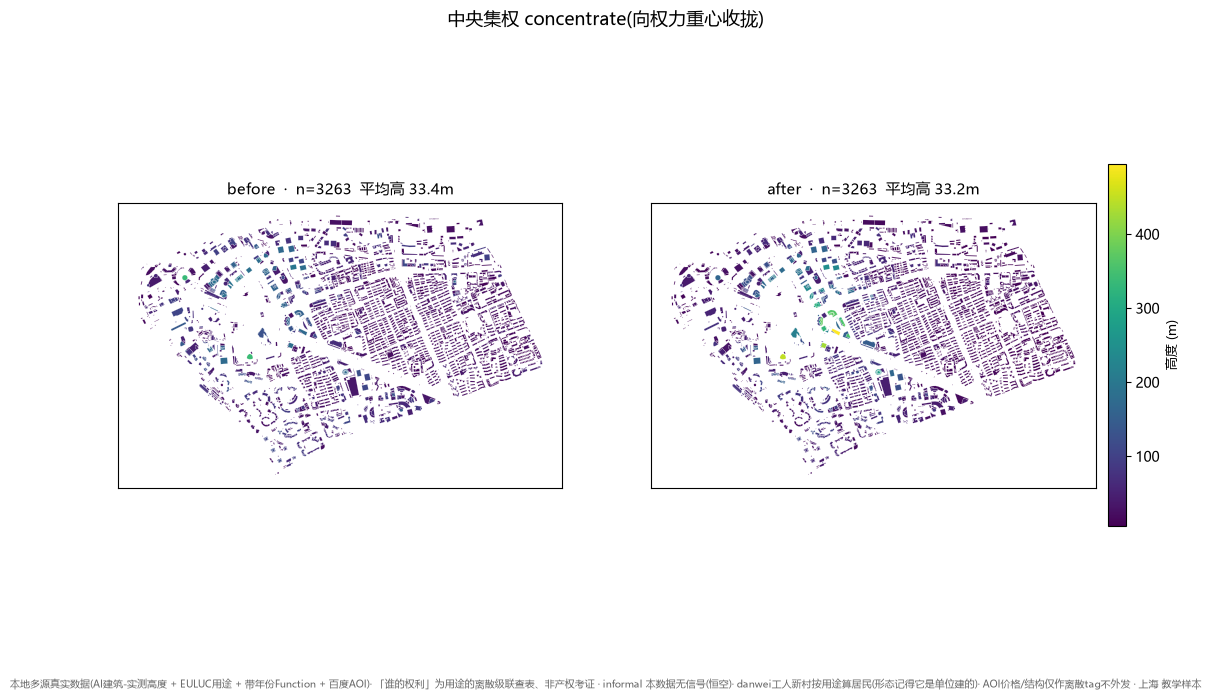

In [4]:
a2 = ops.infill(b, target=["resident", "developer"], cell_m2=120, min_h=6, max_h=21)
plots.operator_demo(b, a2, "居民自建 infill(cell≈120㎡)", color="h")
ac = ops.concentrate(b)
plots.operator_demo(b, ac, "中央集权 concentrate(向权力重心收拢)", color="h")

## 三、权力体制 = 算子的配方(`regimes.yaml`)
把几个动词**按序串起来**,就是一种权力如何重写城市。4 种体制各有一张「配方」:

In [5]:
regs = ops.load_regimes()
prints.regimes(regs)

【开发商主导】细针塔(瘦长比明显升高)
   配方: freeze → split_to_towers → slim → densify
【政府主导 / 中央集权】向权力重心收拢的肥峰(重心集中度普遍翻倍)
   配方: weight_height → concentrate
【居民自建为主】细粒碎化(栋数大增、高度趋低)
   配方: freeze → infill → level
【共享 / 公共平权】均质开放(高度CV 最低)
   配方: open_ground → level


## 四、四种权力 → 四种形态(同色阶横比)
同一座城市、同一批楼,套四种权力体制。**形态差异不是换了数据,纯粹来自「谁更有权、用什么动词」。**

  -> saved out\lujiazui\Step_04\20260701_034730\04_regime_compare.png


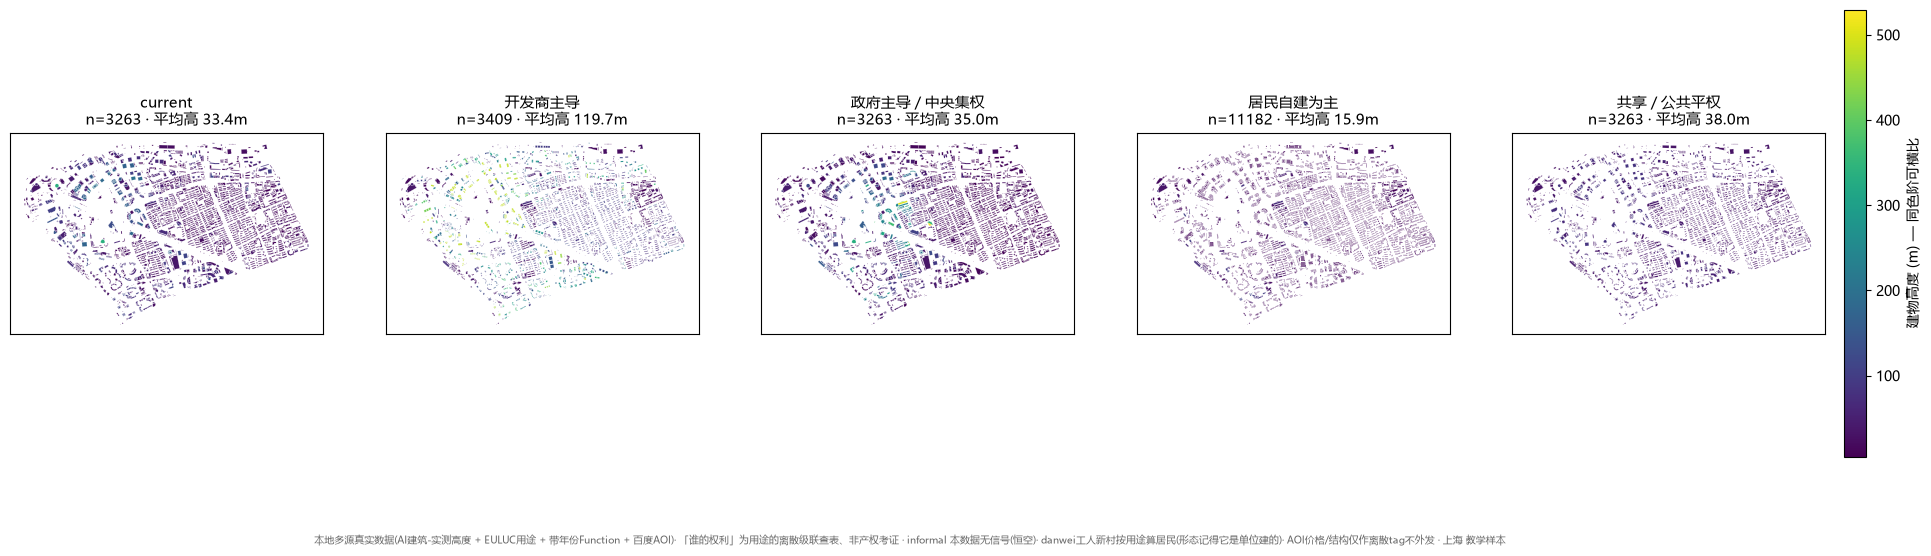

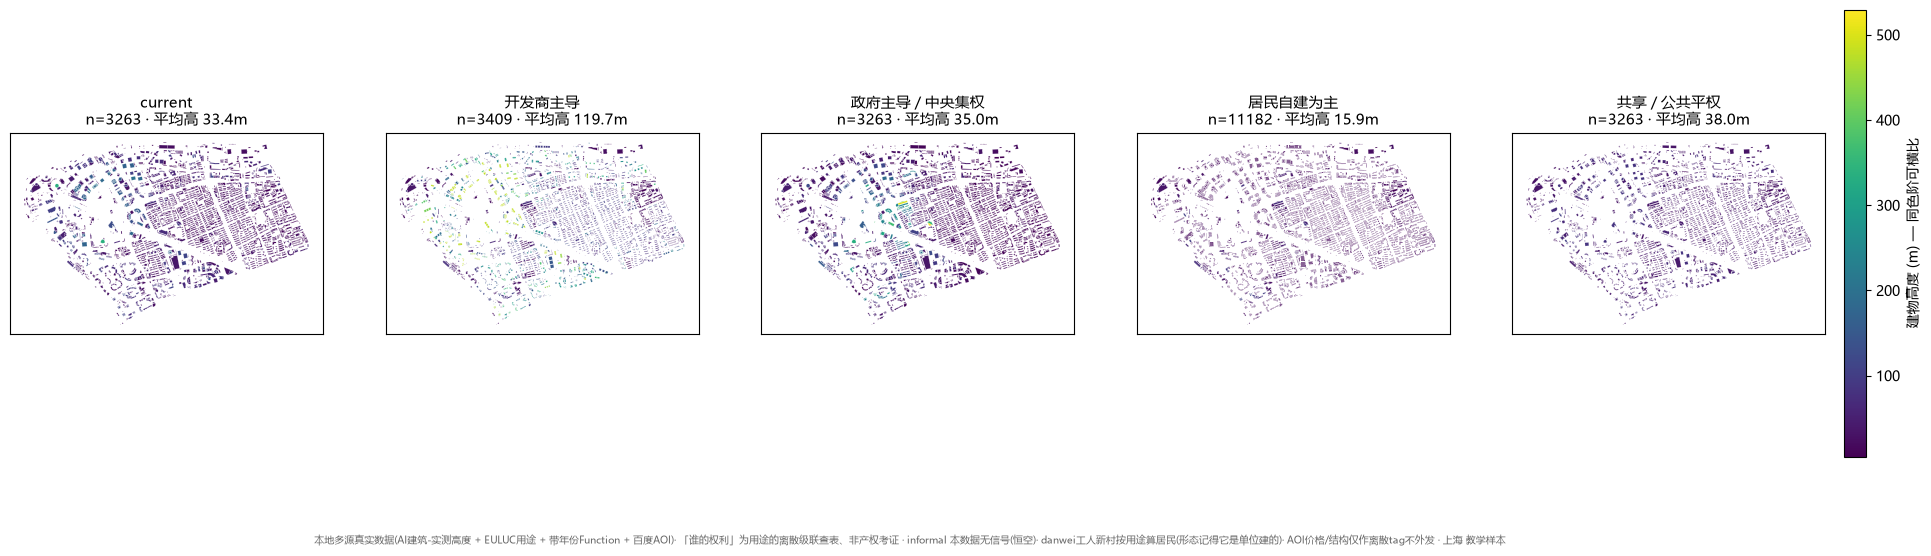

In [6]:
after = {n: ops.apply_regime(recs, regs[n]) for n in regs}
labels = {n: regs[n]["label"] for n in regs}
plots.regime_compare(recs, after, labels=labels)

## 五、形态指纹(measure.py 量化)
肉眼之外,用指标坐实每种权力的「指纹」:开发商=瘦长比飙升(细针塔);政府=重心集中度翻倍(向权力重心收拢);
居民=栋数暴涨(细粒碎化);共享=高度CV 最低(均质)。

  -> saved out\lujiazui\Step_04\20260701_034730\05_fingerprint_bars.png


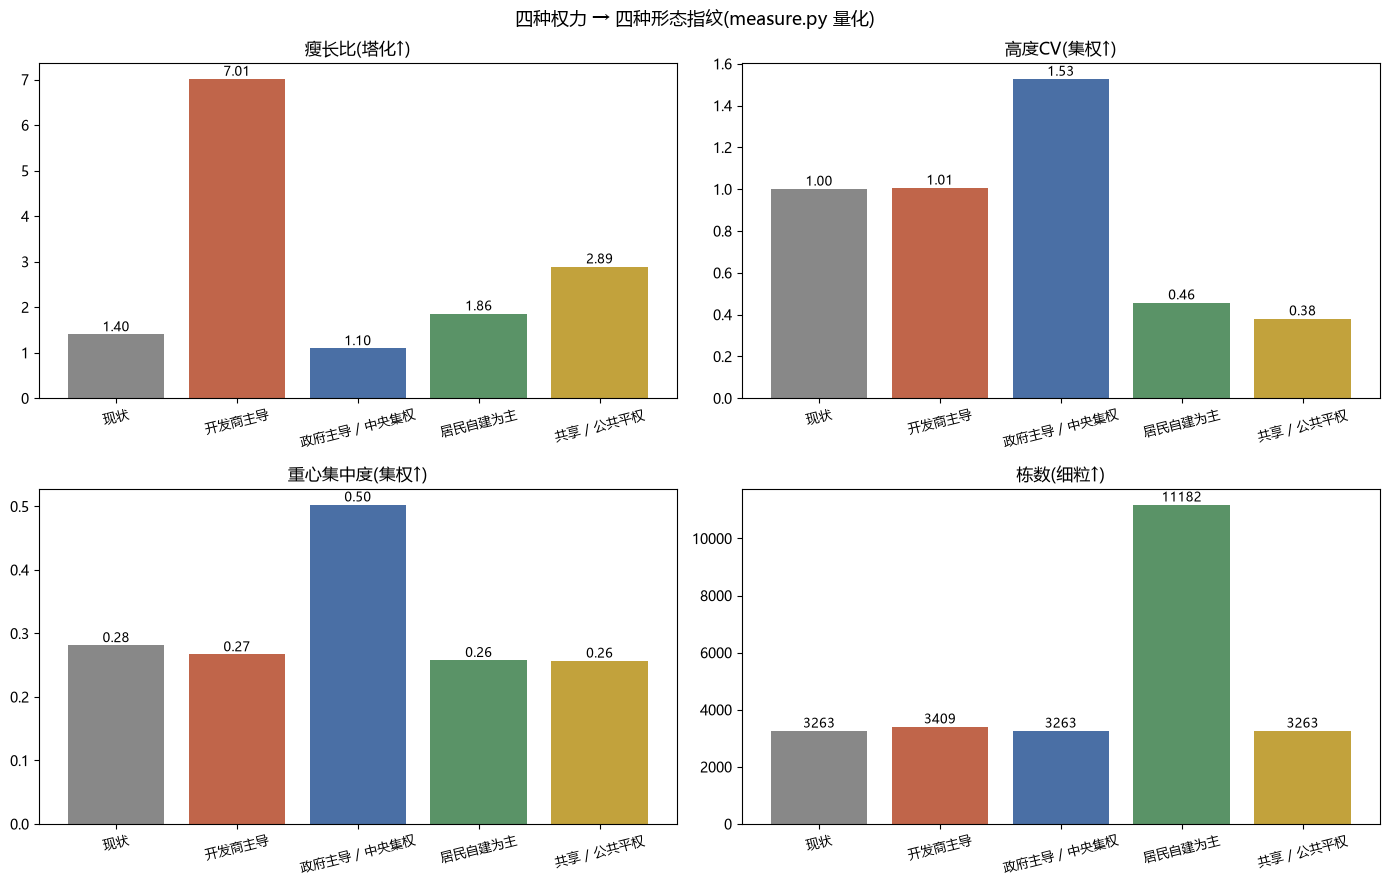

  现状                   瘦长 1.40 · 高度CV 1.00 · 重心集中 0.28 · 栋数 3263
  开发商主导                瘦长 7.01 · 高度CV 1.01 · 重心集中 0.27 · 栋数 3409
  政府主导 / 中央集权          瘦长 1.10 · 高度CV 1.53 · 重心集中 0.50 · 栋数 3263
  居民自建为主               瘦长 1.86 · 高度CV 0.46 · 重心集中 0.26 · 栋数 11182
  共享 / 公共平权            瘦长 2.89 · 高度CV 0.38 · 重心集中 0.26 · 栋数 3263


In [7]:
rows, _ = M.compare(recs, after, config.SLUG)
plots.fingerprint_bars(rows, labels={"current": "现状", **labels})
prints.fingerprints(rows, {"current": "现状", **labels})

## 六、权力的几何逻辑对基底不变,但结果在乎基底
把 `config.py` 的 `SLUG` 从 `lujiazui`(CBD 超高层)换成 `yuyuan`(里弄)或 `caoyang`(工人新村),
**重跑这本**:同一个 `developer_led` 配方,盖在里弄和盖在 CBD **不会长成一样**。
> 权力 × 在地是一场对话,不是盖章。这正是为什么我们坚持跑**真实多源数据**,而不是合成方块。

## 七、动手:复制粘贴换一个算子
算子就是 `recs -> recs` 的纯函数。下面**在 notebook 里**定义一个你自己的算子、登记、用进配方——
不必改 `engine/`。完整模板与说明见 **`算子替换指南.md`**。

  -> saved out\lujiazui\Step_04\20260701_034730\06_operator_demo.png


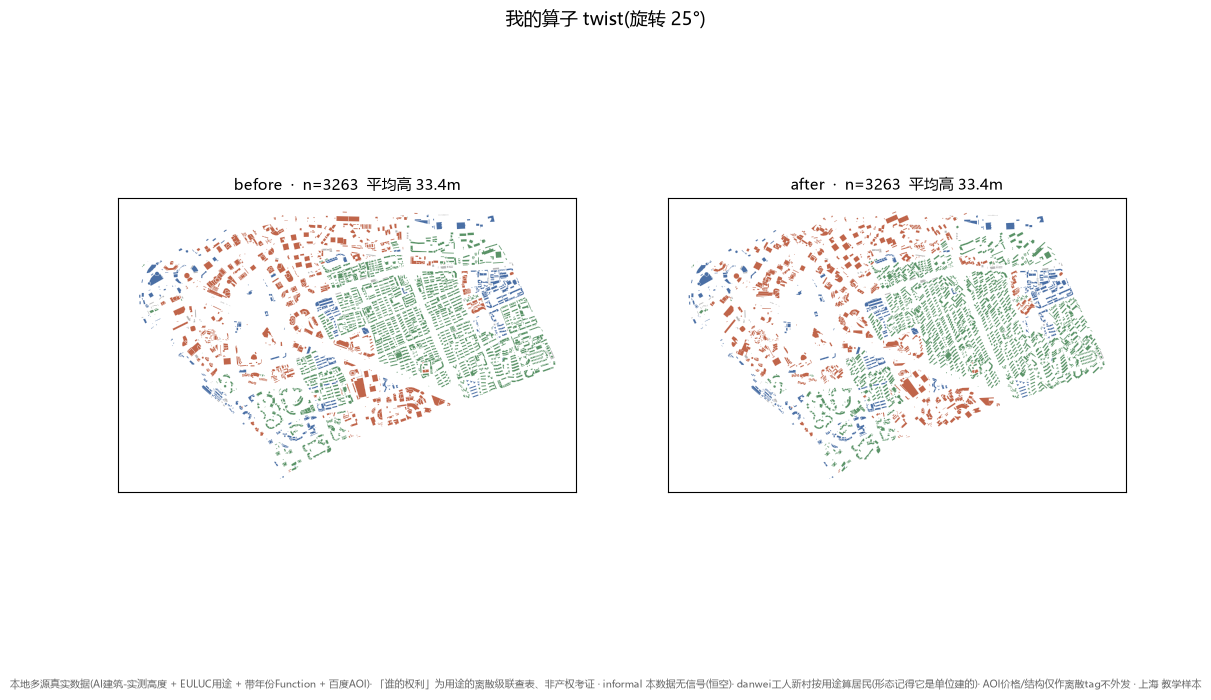

现在 OPS 里多了: True


In [8]:
import shapely.affinity as aff

def twist(recs, target, deg=18):
    """我的算子:把目标楼的 footprint 旋转 deg 度(示范——你可以换成任何形态操作)。"""
    out = [dict(r) for r in recs]
    for r in out:
        if r["sh"] in target and not r.get("frozen"):
            r["geom"] = aff.rotate(r["geom"], deg, origin="centroid")
    return out

ops.register("twist", twist)                       # 登记到算子表(运行时,不改文件)
a3 = twist(b, target=["resident", "developer"], deg=25)
plots.operator_demo(b, a3, "我的算子 twist(旋转 25°)")
prints.registered("twist")

**用进配方**:把 `twist` 写进一条 `steps`,`apply_regime` 就会按序施加它——和内置算子完全平权。
```yaml
my_regime:
  steps:
    - {op: freeze, who: [state]}
    - {op: twist, target: [resident, developer], deg: 25}
    - {op: densify, target: [resident, developer], far_gain: 1.5}
```
> 这就是这套框架的核心承诺:**权力体制 = 算子的配方,而算子可教、可改、可复制粘贴。**

## 诚实边界
这些 regime → 形态是**教学假设 / 可争论的语言**,不是经验断言或真实规划预测。
简化算子不含退线/日照/产权/参与;`informal` 无信号恒空;`danwei` 国家属性在用途数据里看不见。零 AI 推断。